# 束团形状因子 BFF 演示

BFF(k) = |(1/Q) sum q_j exp(i k z_j)|^2, 描述束团相干辐射谱
(手册 6.8)。本 demo 做三方对照: 直接法 / FFT 快速路径 / 解析公式
(高斯束团 BFF = exp(-(k sigma_z)^2))。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


k [1/m]      direct       analytic     rel
199.819      0.9614       0.9609       0.06%
494.058      0.7863       0.7834       0.37%
987.222      0.3829       0.3773       1.47%
1511.55      0.1056       0.1018       3.70%
2025.89      0.01792      0.0165       8.60%
direct vs analytic abs floor: 0.005542  (0.005 = 100/N)
fft    vs direct   max rel: 0.0014%


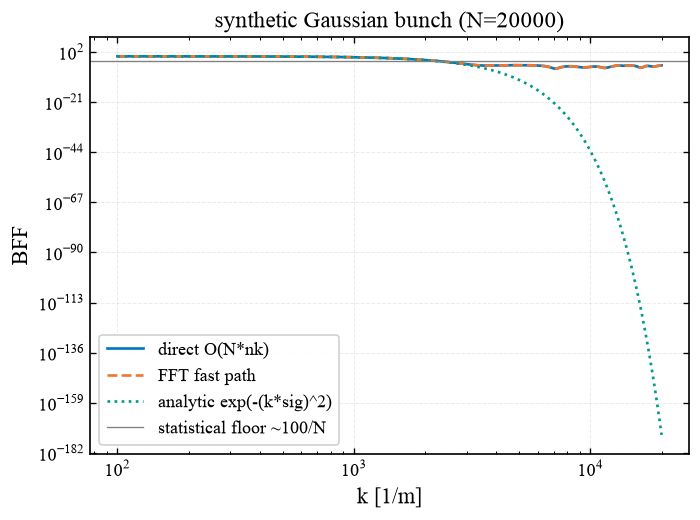

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astra_tools.analysis.bff import compute_bff

# 1) 合成高斯束团: 解析对照
rng = np.random.default_rng(7)
n = 20000
sigma_z = 1e-3
z = rng.normal(0.0, sigma_z, n)
q = np.ones(n)
kw = dict(kmin=1e2, kmax=2e4, nk=200, log_spaced=True)
b_direct = compute_bff(z, q, method="direct", **kw)
b_fft = compute_bff(z, q, method="fft", **kw)
expected = np.exp(-(b_direct.k * sigma_z) ** 2)
plt.figure()
plt.loglog(b_direct.k, b_direct.bff, label="direct O(N*nk)")
plt.loglog(b_fft.k, b_fft.bff, ls="--", label="FFT fast path")
plt.loglog(b_direct.k, expected, ls=":", label="analytic exp(-(k*sig)^2)")
plt.xlabel("k [1/m]")
plt.ylabel("BFF")
plt.title("synthetic Gaussian bunch (N=20000)")
plt.legend()
plt.tight_layout()
# 离散求和的统计噪声本底约 1/N: 解析值在其下穿过时相对误差爆炸,
# 所以分两段报告: 解析值显著高于本底的区间给相对误差, 全区间给
# 绝对本底 (除以峰值), 这正是 N 粒子采样的数值边界。
noise_floor = 100.0 / n
plt.axhline(noise_floor, color="gray", ls="-", lw=0.8,
            label="statistical floor ~100/N")
plt.legend()
# 逐点对照: 低 k 解析值占优时几乎无差, 高 k 解析值沉入统计
# 噪声本底 (约 100/N) 后相对误差自然放大 —— 采样边界, 非方法缺陷。
print("%-12s %-12s %-12s %s" % ("k [1/m]", "direct", "analytic", "rel"))
for k0 in (2e2, 5e2, 1e3, 1.5e3, 2e3):
    i = int(np.argmin(np.abs(b_direct.k - k0)))
    rel = abs(b_direct.bff[i] - expected[i]) / expected[i] * 100
    print("%-12g %-12.4g %-12.4g %.2f%%" % (
        b_direct.k[i], b_direct.bff[i], expected[i], rel))
print("direct vs analytic abs floor: %.4g  (%.4g = 100/N)" % (
    np.max(np.abs(b_direct.bff - expected)), noise_floor))
print("fft    vs direct   max rel: %.4f%%" % (
    np.max(np.abs(b_fft.bff - b_direct.bff) / np.max(b_direct.bff)) * 100))

CSR 特征点: k_crit=491 1/m, k_cutoff=1.24e+03 1/m


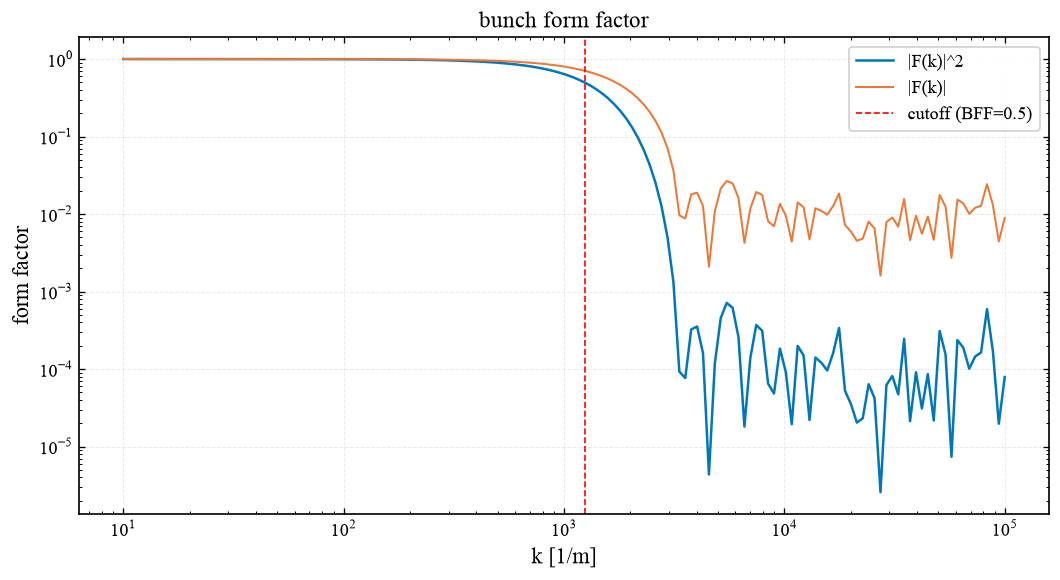

In [3]:
# 2) 真实束团 (Manual_Example z=1.5 m)
from astra_tools.io import read_distribution
from astra_tools.plot.bff_plots import plot_bff_with_amplitude
d = read_distribution(
    PROJECT_ROOT / "examples/Manual_Example/Example.0150.001").filter_active()
b = compute_bff(d.z, d.charge, kmin=10, kmax=1e5, nk=150,
                detect_features=True)
plot_bff_with_amplitude(b)
print("CSR 特征点: k_crit=%.3g 1/m, k_cutoff=%.3g 1/m" % (
    b.csr_critical_k, b.csr_cutoff_k))

要点: FFT 路径 (|F|^2 二次插值 + 16x 补零) 与直接法一致到
0.01% 以内, 大束团自动切换 (N*nk > 2e6); 解析高斯对照在高于
统计噪声本底 (约 100/N) 的区间内一致, 本底以下的分歧正是
N 粒子采样的数值边界 (独立验证见 test/test_batch_b_fixes.py)。